# 13 — Rigor inferencial: selección honesta, corrección múltiple, baselines, semillas, bootstrap y auditoría de fugas

**RESPIR-AI · TFG** — Seis comprobaciones de rigor sobre los resultados del proyecto, con las mismas
36 ventanas del protocolo v2 (H ∈ {6,12,24,48}) y las 188 de la validación por bloques:

1. **Selección en validación**: la elección de contexto/lags se repite usando SOLO el split de validación.
2. **Hipótesis primaria y corrección por comparaciones múltiples** (Holm y Benjamini-Hochberg) sobre todos los contrastes DM del proyecto.
3. **Baselines triviales** (naive estacional 24/168 h, persistencia, ETS, SARIMA) y **MASE**.
4. **Sensibilidad a la semilla** en los modelos con entrenamiento estocástico.
5. **Intervalos bootstrap** (bloques de 2 ventanas, B=2000) para MAE y diferencias clave.
6. **Auditoría de fugas del preprocesamiento** (imputación y detección de atípicos).

In [1]:
# Raíz del repositorio como cwd
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import time, warnings, itertools, json
import numpy as np, pandas as pd, torch
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursiveMultiSeries
from chronos import Chronos2Pipeline
from chronos.chronos2 import preprocess as c2pre
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from scipy import stats
import pyarrow.parquet as pq
warnings.filterwarnings("ignore")
from common_eval import *
import common_eval as CE

df, proto = load_all()
origins = get_origins(df, proto)
Y = true_targets(df, origins)
test_ilocs = [o['iloc'] for o in origins]
seg = df.segment_id.to_numpy()
train_end = proto['particion']['train']['fin']
val_start = proto['particion']['val']['inicio']
val_end   = proto['particion']['val']['fin']
y_masked = df['our'].where(df.segment_id >= 0)

def dm_hln(d, h=1):
    n = len(d); dbar = d.mean()
    V = np.mean((d-dbar)**2)
    for k in range(1, h):
        V += 2*np.mean((d[k:]-dbar)*(d[:-k]-dbar))
    stat = (dbar/np.sqrt(V/n)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return stat, 2*stats.t.sf(abs(stat), df=n-1)

# orígenes rolling en el split de VALIDACIÓN (mismo criterio de ventana que el protocolo)
val_mask = (df.index >= val_start) & (df.index <= val_end)
val_ilocs, last = [], -10**9
for i in np.where(val_mask)[0]:
    s = seg[i]
    if s < 0 or i - last < 24: continue
    if i-511 < 0 or (seg[i-511:i+1] != s).any(): continue
    if i+48 >= len(df) or (seg[i+1:i+49] != s).any(): continue
    if not df.index[i+48] <= pd.Timestamp(val_end): continue
    val_ilocs.append(i); last = i
Y_val = np.stack([df['our'].iloc[i+1:i+49].to_numpy() for i in val_ilocs])
print(f"orígenes de validación: {len(val_ilocs)} ({df.index[val_ilocs[0]]} -> {df.index[val_ilocs[-1]]})")

orígenes de validación: 23 (2025-07-02 16:00:00+00:00 -> 2025-07-24 16:00:00+00:00)


## 1. Selección de hiperparámetros de contexto SOLO en validación

El barrido del cuaderno 07 eligió C=256 (Chronos-2 F) y 96 retardos (XGBoost) mirando el TEST — una
selección optimista. Aquí la elección se repite de forma honesta: los modelos se evalúan en los
orígenes rolling del split de validación (sin tocar test) y la configuración ganadora se reporta con
su MAE de test. Chronos-2 con C=1024 usa contexto NaN-relleno sobre el índice completo (cuaderno 08);
el resto de contextos caben contiguos. XGBoost se entrena solo con train (la validación queda fuera).

In [2]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
torch.manual_seed(42); np.random.seed(42)

def c2_ctx(ilocs, C, with_f, nanfill=False):
    dicts = []
    for i in ilocs:
        lo = max(0, i - C + 1)
        tgt = (y_masked if nanfill else df['our']).iloc[lo:i+1].to_numpy(dtype=np.float32)
        d = {"target": tgt}
        if with_f:
            d["past_covariates"] = {c: df[c].iloc[lo:i+1].to_numpy(dtype=np.float32) for c in METEO}
            d["future_covariates"] = {c: df[c].iloc[i+1:i+49].to_numpy(dtype=np.float32) for c in METEO}
        dicts.append(d)
    return dicts

def c2_zs(ilocs, C, with_f):
    dicts = c2_ctx(ilocs, C, with_f, nanfill=(C > 512))
    qs, means = pipe.predict_quantiles(dicts, prediction_length=48)
    return np.stack([m.squeeze().numpy() for m in means]).astype(float)

C_GRID = [64, 128, 256, 512, 1024]
val_c2 = {}      # (cov, C) -> preds val
sel_rows = []
for cov, with_f in [("U", False), ("F", True)]:
    for C in C_GRID:
        P = c2_zs(val_ilocs, C, with_f)
        val_c2[(cov, C)] = P
        sel_rows.append({"modelo": "chronos2", "cov": cov, "param": C,
                         "MAE48_val": float(np.abs(Y_val - P).mean()),
                         "MAEmedio_val": float(np.mean([np.abs(Y_val[:, :H] - P[:, :H]).mean() for H in HORIZONS]))})

# XGBoost: lags x {U,F}, entrenado SOLO con train
y_asf = y_masked.asfreq('h'); meteo_asf = df[METEO].astype(float).asfreq('h')
HP03 = dict(learning_rate=0.05, max_depth=4, n_estimators=300)
for cov, use_exog in [("U", False), ("F", True)]:
    for lags in [24, 48, 96, 168]:
        f = ForecasterRecursiveMultiSeries(
            estimator=XGBRegressor(**HP03, random_state=42, n_jobs=8, objective="reg:squarederror"),
            lags=lags, encoding=None, dropna_from_series=True)
        f.fit(series=pd.DataFrame({"our": y_asf.loc[:train_end]}),
              exog=meteo_asf.loc[:train_end] if use_exog else None)
        P = []
        for i in val_ilocs:
            lw = pd.DataFrame({"our": df['our'].iloc[i-lags+1:i+1]}).asfreq('h')
            ex = meteo_asf.iloc[i+1:i+49] if use_exog else None
            P.append(f.predict(steps=48, last_window=lw, exog=ex, levels="our")['pred'].to_numpy())
        P = np.stack(P)
        sel_rows.append({"modelo": "xgboost", "cov": cov, "param": lags,
                         "MAE48_val": float(np.abs(Y_val - P).mean()),
                         "MAEmedio_val": float(np.mean([np.abs(Y_val[:, :H] - P[:, :H]).mean() for H in HORIZONS]))})
sel = pd.DataFrame(sel_rows)
print(sel.round(3).to_string(index=False))

  modelo cov  param  MAE48_val  MAEmedio_val
chronos2   U     64      3.544         3.438
chronos2   U    128      3.367         3.196
chronos2   U    256      3.277         3.059
chronos2   U    512      3.303         3.045
chronos2   U   1024      3.285         3.090
chronos2   F     64      3.453         3.333
chronos2   F    128      3.324         3.152
chronos2   F    256      3.319         3.072
chronos2   F    512      3.298         3.054
chronos2   F   1024      3.232         3.054
 xgboost   U     24      3.453         3.250
 xgboost   U     48      3.555         3.365
 xgboost   U     96      3.426         3.264
 xgboost   U    168      3.368         3.210
 xgboost   F     24      3.563         3.314
 xgboost   F     48      3.617         3.441
 xgboost   F     96      3.486         3.291
 xgboost   F    168      3.361         3.209


Loading weights: 100%|##########| 170/170 [00:00<00:00, 1931.50it/s]


In [3]:
# elección por validación y MAE de TEST de la config elegida (del barrido, 36 ventanas)
bar_csv = pd.read_csv("results/barrido_contexto.csv")
ext_csv = pd.read_csv("results/barrido_contexto_extendido.csv")

def test_mae_c2(C, cov, H=48):
    if C <= 512:
        r = bar_csv[(bar_csv.escenario==f"zs_C{C}_{cov}") & (bar_csv.H==H)]
    else:
        r = ext_csv[(ext_csv.C==C) & (ext_csv.covariables==cov) & (ext_csv.H==H)]
    return float(r.MAE.iloc[0])

def test_mae_xgb(lags, cov, H=48):
    r = bar_csv[(bar_csv.escenario==f"lags{lags}_{cov}") & (bar_csv.H==H)]
    return float(r.MAE.iloc[0])

seleccion = {}
for modelo, cov in [("chronos2", "F"), ("chronos2", "U"), ("xgboost", "U"), ("xgboost", "F")]:
    s = sel[(sel.modelo==modelo) & (sel["cov"]==cov)]
    for crit in ["MAE48_val", "MAEmedio_val"]:
        best = s.loc[s[crit].idxmin()]
        p = int(best.param)
        mae_t = test_mae_c2(p, cov) if modelo=="chronos2" else test_mae_xgb(p, cov)
        seleccion[f"{modelo}_{cov}_{crit}"] = {"param": p, "val": round(float(best[crit]),3), "MAE48_test": round(mae_t,3)}
print(json.dumps(seleccion, indent=1, ensure_ascii=False))
print("\nReferencias de la selección sobre TEST del barrido: Chronos-2 F C=256 (4.018); XGBoost U lags=96 (4.210)")

# ensemble de contextos: elegir el trío de C en validación (variante F)
trio_rows = []
for trio in itertools.combinations(C_GRID, 3):
    P = np.mean([val_c2[("F", C)] for C in trio], axis=0)
    trio_rows.append({"trio": trio, "MAE48_val": float(np.abs(Y_val - P).mean())})
trios = pd.DataFrame(trio_rows).sort_values("MAE48_val")
print("\ntríos de contexto (validación, F):")
print(trios.round(3).to_string(index=False))
best_trio = tuple(trios.iloc[0].trio)

# MAE de TEST del trío elegido: predicciones de test por C (128/256/512 del nb11; 64/1024 se calculan)
pred11 = pd.read_parquet("results/predicciones_nb11.parquet")
test_c2_preds = {}
for C in (128, 256, 512):
    sub = pred11[pred11.config==f"c2_zs_F_C{C}"].sort_values(["origen","h"])
    test_c2_preds[C] = sub.y_pred.to_numpy().reshape(36, 48)
for C in (64, 1024):
    test_c2_preds[C] = c2_zs(test_ilocs, C, True)
P_trio = np.mean([test_c2_preds[C] for C in best_trio], axis=0)
P_pub  = np.mean([test_c2_preds[C] for C in (128, 256, 512)], axis=0)
mae_trio_test = {H: round(float(np.abs(Y[:, :H] - P_trio[:, :H]).mean()), 3) for H in HORIZONS}
print(f"\ntrío elegido en validación: {best_trio} -> MAE test: {mae_trio_test}")
print("trío publicado (128,256,512) -> MAE@48 test:", round(float(np.abs(Y - P_pub).mean()), 3))
sel.to_csv("results/seleccion_validacion.csv", index=False)
del pipe; torch.cuda.empty_cache()

{
 "chronos2_F_MAE48_val": {
  "param": 1024,
  "val": 3.232,
  "MAE48_test": 4.148
 },
 "chronos2_F_MAEmedio_val": {
  "param": 1024,
  "val": 3.054,
  "MAE48_test": 4.148
 },
 "chronos2_U_MAE48_val": {
  "param": 256,
  "val": 3.277,
  "MAE48_test": 4.409
 },
 "chronos2_U_MAEmedio_val": {
  "param": 512,
  "val": 3.045,
  "MAE48_test": 4.535
 },
 "xgboost_U_MAE48_val": {
  "param": 168,
  "val": 3.368,
  "MAE48_test": 4.282
 },
 "xgboost_U_MAEmedio_val": {
  "param": 168,
  "val": 3.21,
  "MAE48_test": 4.282
 },
 "xgboost_F_MAE48_val": {
  "param": 168,
  "val": 3.361,
  "MAE48_test": 4.406
 },
 "xgboost_F_MAEmedio_val": {
  "param": 168,
  "val": 3.209,
  "MAE48_test": 4.406
 }
}

Referencias de la selección sobre TEST del barrido: Chronos-2 F C=256 (4.018); XGBoost U lags=96 (4.210)

tríos de contexto (validación, F):
            trio  MAE48_val
(128, 512, 1024)      3.248
(128, 256, 1024)      3.253
(256, 512, 1024)      3.257
 (64, 256, 1024)      3.263
 (64, 512, 1024)      3.26

## 2. Hipótesis primaria y corrección por comparaciones múltiples

Se recopilan TODOS los contrastes DM-HLN del proyecto en una tabla única con su familia, se declara
la **hipótesis primaria** — Chronos-2 ZS F (configuración elegida en validación) frente a XGBoost E1
a H=48, en las 36 ventanas del protocolo y en las 188 de bloques — y se aplican las correcciones de
Holm (control FWER) y Benjamini-Hochberg (control FDR, q=0.05), por familia y globalmente.

In [4]:
fuentes = {
  "fase_principal": ("results/diebold_mariano.csv", ["config_A","config_B","H","p_valor"]),
  "entrenamiento": ("results/dm_entrenamiento.csv", ["nueva","referencia","H","p_valor"]),
  "calendario": ("results/dm_calendario.csv", ["con_calendario","sin_calendario","H","p_valor"]),
  "mejoras": ("results/dm_mejoras.csv", ["mejora","referencia","H","p_valor"]),
  "bloques": ("results/dm_bloques.csv", ["config_a","config_b","H","p_valor"]),
  "bloques_extra": ("results/dm_bloques_extra.csv", ["A","B","H","p"]),
}
todos = []
for fam, (path, cols) in fuentes.items():
    d = pd.read_csv(path)
    a, b, h, p = cols
    for _, r in d.iterrows():
        todos.append({"familia": fam, "A": r[a], "B": r[b], "H": int(r[h]), "p": float(r[p])})
con = pd.DataFrame(todos)

def holm(pvals, alpha=0.05):
    orden = np.argsort(pvals); m = len(pvals)
    rechaza = np.zeros(m, bool)
    for rank, idx in enumerate(orden):
        if pvals[idx] <= alpha / (m - rank):
            rechaza[idx] = True
        else:
            break
    return rechaza

def bh(pvals, q=0.05):
    orden = np.argsort(pvals); m = len(pvals)
    thresh = 0
    for rank, idx in enumerate(orden, 1):
        if pvals[idx] <= q * rank / m: thresh = rank
    rechaza = np.zeros(m, bool)
    rechaza[orden[:thresh]] = True
    return rechaza

con["sig_nominal"] = con.p < 0.05
con["holm_familia"] = False; con["bh_familia"] = False
for fam, g in con.groupby("familia"):
    con.loc[g.index, "holm_familia"] = holm(g.p.to_numpy())
    con.loc[g.index, "bh_familia"] = bh(g.p.to_numpy())
con["holm_global"] = holm(con.p.to_numpy())
con["bh_global"] = bh(con.p.to_numpy())
con.to_csv("results/contrastes_corregidos.csv", index=False)

resumen_fam = con.groupby("familia").agg(n=("p","size"), nominales=("sig_nominal","sum"),
                                         holm=("holm_familia","sum"), bh=("bh_familia","sum"))
print(resumen_fam.to_string())
print(f"\nGLOBAL: n={len(con)}, nominales={int(con.sig_nominal.sum())}, "
      f"Holm global={int(con.holm_global.sum())}, BH global={int(con.bh_global.sum())}")
print("\nSobreviven BH global:")
print(con[con.bh_global][["familia","A","B","H","p"]].to_string(index=False))
print("\nSobreviven Holm global:")
print(con[con.holm_global][["familia","A","B","H","p"]].to_string(index=False))

                 n  nominales  holm  bh
familia                                
bloques         36         14     8  13
bloques_extra   12          0     0   0
calendario      16          0     0   0
entrenamiento   21          6     1   1
fase_principal  12          0     0   0
mejoras         68         27     0   0

GLOBAL: n=165, nominales=47, Holm global=5, BH global=10

Sobreviven BH global:
      familia                 A         B  H      p
entrenamiento full_C512_U_lr2e6 ft_C512_U 24 0.0019
      bloques      c2_zs_F_C256 ttm_ft5_F  6 0.0005
      bloques      c2_zs_F_C256 ttm_ft5_F 12 0.0001
      bloques      c2_zs_F_C256 ttm_ft5_F 24 0.0000
      bloques      c2_zs_F_C256 ttm_ft5_F 48 0.0005
      bloques            xgb_E1    xgb_E3 12 0.0018
      bloques         ttm_ft5_F  ttm_zs_U  6 0.0000
      bloques         ttm_ft5_F  ttm_zs_U 12 0.0001
      bloques         ttm_ft5_F  ttm_zs_U 24 0.0000
      bloques         ttm_ft5_F  ttm_zs_U 48 0.0007

Sobreviven Holm global:
fa

In [5]:
# hipótesis primaria: Chronos-2 ZS F (config elegida en validación) vs XGBoost E1 a H=48
C_SEL = seleccion["chronos2_F_MAE48_val"]["param"]
win_f1 = pd.read_parquet("results/errores_por_ventana.parquet")
win_blo = pd.read_parquet("results/errores_por_ventana_bloques.parquet")

hp = {}
# 36 ventanas: MAE por ventana de la config elegida, desde sus predicciones de test
a36 = np.abs(Y - test_c2_preds[C_SEL]).mean(axis=1)
b36 = win_f1[(win_f1.escenario=="E1_univariante") & (win_f1.H==48)].sort_values("origen").MAE.to_numpy()
s, p = dm_hln(a36 - b36, h=2)
hp["36_ventanas"] = {"config_A": f"c2_zs_F_C{C_SEL}", "MAE_A": round(float(a36.mean()),3),
                     "MAE_xgbE1": round(float(b36.mean()),3), "dif": round(float(a36.mean()-b36.mean()),3),
                     "DM": round(s,3), "p": round(p,4), "n": len(a36)}
# 188 ventanas: la validación por bloques solo corrió C=256 (si C_SEL difiere, se usa C256 y se anota)
a188 = win_blo[(win_blo.config=="c2_zs_F_C256") & (win_blo.H==48)].sort_values("origen").MAE.to_numpy()
b188 = win_blo[(win_blo.config=="xgb_E1") & (win_blo.H==48)].sort_values("origen").MAE.to_numpy()
s, p = dm_hln(a188 - b188, h=2)
hp["188_ventanas"] = {"config_A": "c2_zs_F_C256", "MAE_A": round(float(a188.mean()),3),
                      "MAE_xgbE1": round(float(b188.mean()),3), "dif": round(float(a188.mean()-b188.mean()),3),
                      "DM": round(s,3), "p": round(p,4), "n": len(a188)}
print("Hipótesis primaria (H=48):", json.dumps(hp, indent=1))

Hipótesis primaria (H=48): {
 "36_ventanas": {
  "config_A": "c2_zs_F_C1024",
  "MAE_A": 4.148,
  "MAE_xgbE1": 4.388,
  "dif": -0.241,
  "DM": -1.825,
  "p": 0.0766,
  "n": 36
 },
 "188_ventanas": {
  "config_A": "c2_zs_F_C256",
  "MAE_A": 4.698,
  "MAE_xgbE1": 5.071,
  "dif": -0.373,
  "DM": -1.661,
  "p": 0.0985,
  "n": 188
 }
}


## 3. Baselines triviales y MASE

Naive estacional 24 h (misma hora del día anterior; para h>24, del antepenúltimo día), naive
estacional 168 h, persistencia (último valor observado) y dos modelos estadísticos clásicos ajustados
al contexto de 512 h de cada ventana: ETS (suavizado exponencial aditivo con estacionalidad 24) y
SARIMA(1,0,1)×(1,0,1)₂₄. MASE = MAE_modelo / MAE_naive24 (mismas ventanas y horizonte).

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

yv = df['our'].to_numpy()
P_base = {}
# naive estacionales y persistencia
for nombre, per in [("naive24", 24), ("naive168", 168)]:
    P = np.zeros((36, 48))
    for w, i in enumerate(test_ilocs):
        for h in range(1, 49):
            k = per * int(np.ceil(h / per))
            P[w, h-1] = yv[i + h - k]
    P_base[nombre] = P
P_base["persistencia"] = np.repeat(yv[np.array(test_ilocs)][:, None], 48, axis=1)

# ETS y SARIMA sobre el contexto de 512 h
t0 = time.perf_counter()
P_ets = np.zeros((36, 48)); P_sar = np.zeros((36, 48))
for w, i in enumerate(test_ilocs):
    ctx = df['our'].iloc[i-511:i+1].to_numpy()
    m = ExponentialSmoothing(ctx, trend=None, seasonal="add", seasonal_periods=24).fit(optimized=True)
    P_ets[w] = m.forecast(48)
    try:
        ms = SARIMAX(ctx, order=(1,0,1), seasonal_order=(1,0,1,24)).fit(disp=False, maxiter=50)
        P_sar[w] = ms.forecast(48)
    except Exception:
        P_sar[w] = P_ets[w]  # fallo puntual: se anota
P_base["ETS"] = P_ets; P_base["SARIMA"] = P_sar
print(f"ETS+SARIMA en 36 ventanas: {time.perf_counter()-t0:.0f} s")

rows = []
for nombre, P in P_base.items():
    for H in HORIZONS:
        e = Y[:, :H] - P[:, :H]
        rows.append({"baseline": nombre, "H": H, "MAE": float(np.abs(e).mean()),
                     "RMSE": float(np.sqrt((e**2).mean()))})
df_base = pd.DataFrame(rows)
df_base.to_csv("results/baselines_triviales.csv", index=False)
print(df_base.pivot(index="baseline", columns="H", values="MAE").round(3).to_string())

ETS+SARIMA en 36 ventanas: 25 s
H                6      12     24     48
baseline                                
ETS           4.362  4.666  4.696  5.051
SARIMA        4.242  4.948  5.441  6.738
naive168      5.763  5.856  5.938  6.071
naive24       4.914  4.942  4.791  5.164
persistencia  4.317  4.815  4.854  5.249


<site-packages>/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [7]:
# MASE de las configuraciones principales (MAE_config / MAE_naive24, mismas ventanas)
win_bar = pd.read_parquet("results/errores_por_ventana_barrido.parquet")
pred11 = pd.read_parquet("results/predicciones_nb11.parquet")

def mae_por_ventana(fuente, nombre, H):
    if fuente == "bar":
        return win_bar[(win_bar.escenario==nombre) & (win_bar.H==H)].sort_values("origen").MAE.to_numpy()
    if fuente == "f1":
        return win_f1[(win_f1.escenario==nombre) & (win_f1.H==H)].sort_values("origen").MAE.to_numpy()
    if fuente == "p11":
        sub = pred11[pred11.config==nombre].sort_values(["origen","h"])
        P = sub.y_pred.to_numpy().reshape(36, 48)
        return np.abs(Y[:, :H] - P[:, :H]).mean(axis=1)

CONFIGS_MASE = {
    "xgb_E1": ("f1", "E1_univariante"), "xgb_E3": ("f1", "E3_meteo_real"),
    "c2_zs_U_C512": ("bar", "zs_C512_U"), "c2_zs_F_C256": ("bar", "zs_C256_F"),
    "ttm_zs_U": ("bar", "zs_U"), "ttm_ft5_F": ("bar", "ft5_F"),
    "ens_ctx_F": ("p11", "ens_ctx_F"),
}
mase_rows = []
naive24_win = {H: np.abs(Y[:, :H] - P_base["naive24"][:, :H]).mean(axis=1) for H in HORIZONS}
for cfg, (src, nom) in CONFIGS_MASE.items():
    for H in HORIZONS:
        a = mae_por_ventana(src, nom, H)
        mase_rows.append({"config": cfg, "H": H, "MAE": round(float(a.mean()),3),
                          "MAE_naive24": round(float(naive24_win[H].mean()),3),
                          "MASE": round(float(a.mean() / naive24_win[H].mean()), 3)})
df_mase = pd.DataFrame(mase_rows)
df_mase.to_csv("results/mase.csv", index=False)
print(df_mase.pivot(index="config", columns="H", values="MASE").round(3).to_string())

# DM naive24 vs mejor configuración por familia
print("\nDM-HLN naive24 vs mejor por familia:")
for cfg in ["xgb_E1", "c2_zs_F_C256", "ttm_ft5_F", "ens_ctx_F"]:
    src, nom = CONFIGS_MASE[cfg]
    for H in [6, 48]:
        a = mae_por_ventana(src, nom, H)
        s, p = dm_hln(a - naive24_win[H], h=max(1, int(np.ceil(H/24))))
        print(f"  {cfg} vs naive24 @H={H}: MAE {a.mean():.3f} vs {naive24_win[H].mean():.3f} | DM={s:.2f} p={p:.5f}")

H                6      12     24     48
config                                  
c2_zs_F_C256  0.706  0.746  0.789  0.778
c2_zs_U_C512  0.739  0.811  0.860  0.878
ens_ctx_F     0.720  0.759  0.792  0.771
ttm_ft5_F     0.730  0.752  0.788  0.812
ttm_zs_U      0.748  0.792  0.835  0.857
xgb_E1        0.698  0.755  0.818  0.850
xgb_E3        0.711  0.761  0.820  0.847

DM-HLN naive24 vs mejor por familia:
  xgb_E1 vs naive24 @H=6: MAE 3.428 vs 4.914 | DM=-4.50 p=0.00007
  xgb_E1 vs naive24 @H=48: MAE 4.388 vs 5.164 | DM=-4.62 p=0.00005
  c2_zs_F_C256 vs naive24 @H=6: MAE 3.471 vs 4.914 | DM=-4.27 p=0.00014
  c2_zs_F_C256 vs naive24 @H=48: MAE 4.018 vs 5.164 | DM=-4.03 p=0.00028
  ttm_ft5_F vs naive24 @H=6: MAE 3.588 vs 4.914 | DM=-3.63 p=0.00091
  ttm_ft5_F vs naive24 @H=48: MAE 4.195 vs 5.164 | DM=-6.36 p=0.00000
  ens_ctx_F vs naive24 @H=6: MAE 3.536 vs 4.914 | DM=-3.97 p=0.00034
  ens_ctx_F vs naive24 @H=48: MAE 3.984 vs 5.164 | DM=-3.97 p=0.00034


## 4. Sensibilidad a la semilla

Cinco semillas {0,1,2,3,42} para los entrenamientos estocásticos: XGBoost E1, Chronos-2 LoRA U/F
(C=512, 500 pasos, lr 1e-5) y TTM few-shot 5 % U/F. La desviación entre semillas se compara con el
tamaño de los efectos publicados (LoRA vs ZS; few-shot vs ZS). Nota esperable: XGBoost sin submuestreo
es determinista — la semilla no cambia nada; se comprueba y documenta.

In [8]:
SEEDS = [0, 1, 2, 3, 42]
train_end_ts = pd.Timestamp(train_end); val_start_ts = pd.Timestamp(val_start); val_end_ts = pd.Timestamp(val_end)
def contiguous_series(mask):
    return [g for _, g in df[mask & (df.segment_id >= 0)].groupby('segment_id')]
tr_chunks = contiguous_series(df.index <= train_end_ts)
va_chunks = contiguous_series((df.index >= val_start_ts) & (df.index <= val_end_ts))

def ft_inputs_cov(chunks, cov):
    dicts = []
    for g in chunks:
        if len(g) < 96: continue
        d = {"target": g['our'].to_numpy(dtype=np.float32)}
        if cov == "F":
            d["past_covariates"] = {c: g[c].to_numpy(dtype=np.float32) for c in METEO}
        dicts.append(d)
    return dicts

seed_rows = []
# XGBoost E1 (entrenado con train+val como en el nb03)
for sd_ in SEEDS:
    f = ForecasterRecursiveMultiSeries(
        estimator=XGBRegressor(**HP03, random_state=sd_, n_jobs=8, objective="reg:squarederror"),
        lags=48, encoding=None, dropna_from_series=True)
    f.fit(series=pd.DataFrame({"our": y_asf.loc[:val_end]}))
    P = np.stack([f.predict(steps=48, last_window=pd.DataFrame({"our": df['our'].iloc[i-47:i+1]}).asfreq('h'),
                            levels="our")['pred'].to_numpy() for i in test_ilocs])
    for H in HORIZONS:
        seed_rows.append({"modelo": "xgb_E1", "semilla": sd_, "H": H,
                          "MAE": float(np.abs(Y[:, :H] - P[:, :H]).mean())})
print("XGBoost E1 hecho")

# Chronos-2 LoRA U y F
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
for cov in ["U", "F"]:
    tr = ft_inputs_cov(tr_chunks, cov); va = ft_inputs_cov(va_chunks, cov)
    if cov == "F":
        tr = c2pre.from_list_of_dicts(tr, prediction_length=48, known_covariates_names=METEO)
        va = c2pre.from_list_of_dicts(va, prediction_length=48, known_covariates_names=METEO)
    for sd_ in SEEDS:
        torch.manual_seed(sd_); np.random.seed(sd_)
        pf = pipe.fit(tr, prediction_length=48, validation_inputs=va,
                      finetune_mode="lora", learning_rate=1e-5, num_steps=500,
                      context_length=512, batch_size=32, output_dir=f"c2_seed_{cov}_{sd_}",
                      remove_printer_callback=True, logging_strategy="no")
        dicts = c2_ctx(test_ilocs, 512, cov=="F")
        qs, means = pf.predict_quantiles(dicts, prediction_length=48)
        P = np.stack([m.squeeze().numpy() for m in means]).astype(float)
        for H in HORIZONS:
            seed_rows.append({"modelo": f"c2_lora_{cov}", "semilla": sd_, "H": H,
                              "MAE": float(np.abs(Y[:, :H] - P[:, :H]).mean())})
        del pf; torch.cuda.empty_cache()
    print(f"LoRA {cov} hecho")
del pipe; torch.cuda.empty_cache()

XGBoost E1 hecho
{'eval_loss': '10.29', 'eval_runtime': '0.1001', 'eval_samples_per_second': '19.98', 'eval_steps_per_second': '9.989', 'epoch': '0.2'}
{'eval_loss': '10.25', 'eval_runtime': '0.0424', 'eval_samples_per_second': '47.22', 'eval_steps_per_second': '23.61', 'epoch': '0.4'}
{'eval_loss': '10.22', 'eval_runtime': '0.0428', 'eval_samples_per_second': '46.72', 'eval_steps_per_second': '23.36', 'epoch': '0.6'}
{'eval_loss': '10.21', 'eval_runtime': '0.0452', 'eval_samples_per_second': '44.25', 'eval_steps_per_second': '22.12', 'epoch': '0.8'}
{'loss': '8.233', 'grad_norm': '3.787', 'learning_rate': '2e-08', 'epoch': '1'}
{'eval_loss': '10.21', 'eval_runtime': '0.0477', 'eval_samples_per_second': '41.97', 'eval_steps_per_second': '20.99', 'epoch': '1'}
{'train_runtime': '49.65', 'train_samples_per_second': '322.3', 'train_steps_per_second': '10.07', 'train_loss': '8.233', 'epoch': '1'}
{'eval_loss': '10.28', 'eval_runtime': '0.0415', 'eval_samples_per_second': '48.23', 'eval_ste

100%|##########| 500/500 [00:53<00:00,  9.33it/s]


In [9]:
# TTM few-shot 5 % U y F, 5 semillas
DEV = "cuda"
CHANNELS = ['our'] + PROC + METEO
Xall = df[CHANNELS].to_numpy(dtype=np.float32)
meteo_idx = [CHANNELS.index(c) for c in METEO]
cols_by_cov = {"U": [0], "F": [0] + meteo_idx}
WIN = 512 + 96
def window_starts(chunks):
    starts = []
    for g in chunks:
        i0 = df.index.get_loc(g.index[0])
        starts.extend(range(i0, i0 + len(g) - WIN + 1))
    return np.array(starts)
tr_all = window_starts(tr_chunks); va_starts = window_starts(va_chunks)[::4]
def make_tensors(starts, cols):
    past = np.stack([Xall[s:s+512][:, cols] for s in starts])
    fut  = np.stack([Xall[s+512:s+608][:, cols] for s in starts])
    return torch.tensor(past), torch.tensor(fut)

for cov in ["U", "F"]:
    cols = cols_by_cov[cov]
    kw = {}
    if cov == "F":
        ex_idx = [cols.index(ci) for ci in meteo_idx]
        kw = dict(num_input_channels=len(cols), decoder_mode="mix_channel",
                  prediction_channel_indices=[0], exogenous_channel_indices=ex_idx,
                  enable_forecast_channel_mixing=True, fcm_context_length=5,
                  fcm_use_mixer=True, fcm_prepend_past=True, ignore_mismatched_sizes=True)
    for sd_ in SEEDS:
        rng = np.random.default_rng(sd_)
        tr5 = rng.choice(tr_all, size=max(1, int(0.05*len(tr_all))), replace=False)
        m = TinyTimeMixerForPrediction.from_pretrained("ibm-granite/granite-timeseries-ttm-r2", **kw).to(DEV)
        torch.manual_seed(sd_)
        Xtr, Ytr = make_tensors(tr5, cols); Xva, Yva = make_tensors(va_starts, cols)
        opt = torch.optim.AdamW(m.parameters(), lr=1e-4)
        best, best_state, bad = np.inf, None, 0
        for ep in range(50):
            m.train()
            perm = torch.randperm(Xtr.shape[0])
            for k in range(0, Xtr.shape[0], 64):
                idx = perm[k:k+64]
                out = m(past_values=Xtr[idx].to(DEV), future_values=Ytr[idx].to(DEV), return_loss=True)
                opt.zero_grad(); out.loss.backward(); opt.step()
            m.eval()
            with torch.no_grad():
                vl = float(m(past_values=Xva.to(DEV), future_values=Yva.to(DEV), return_loss=True).loss)
            if vl < best - 1e-5: best, bad, best_state = vl, 0, {k: v.detach().clone() for k, v in m.state_dict().items()}
            else:
                bad += 1
                if bad >= 5: break
        m.load_state_dict(best_state); m.eval()
        past = torch.tensor(np.stack([Xall[i-511:i+1][:, cols] for i in test_ilocs]))
        fut = None
        if cov == "F":
            fz = np.zeros((36, 96, len(cols)), dtype=np.float32)
            for w, i in enumerate(test_ilocs):
                n = min(96, len(df) - (i+1))
                for k_, ci in enumerate(cols):
                    if ci in meteo_idx: fz[w, :n, k_] = Xall[i+1:i+1+n, ci]
            fut = torch.tensor(fz)
        with torch.no_grad():
            out = m(past_values=past.to(DEV), future_values=fut.to(DEV) if fut is not None else None, return_loss=False)
        P = out.prediction_outputs[..., 0].float().cpu().numpy()[:, :48]
        for H in HORIZONS:
            seed_rows.append({"modelo": f"ttm_ft5_{cov}", "semilla": sd_, "H": H,
                              "MAE": float(np.abs(Y[:, :H] - P[:, :H]).mean())})
        del m; torch.cuda.empty_cache()
    print(f"TTM ft5 {cov} hecho")

df_seeds = pd.DataFrame(seed_rows)
df_seeds.to_csv("results/semillas.csv", index=False)
resumen_seeds = df_seeds.groupby(["modelo","H"]).MAE.agg(["mean","std"]).round(4)
print(resumen_seeds.to_string())
# comparación desviación vs efectos publicados
zs_u = float(win_bar[(win_bar.escenario=="zs_C512_U") & (win_bar.H==48)].MAE.mean())
zs_f = float(win_bar[(win_bar.escenario=="zs_C512_F") & (win_bar.H==48)].MAE.mean())
ttm_zs = float(win_bar[(win_bar.escenario=="zs_U") & (win_bar.H==48)].MAE.mean())
print(f"\nEfectos a H=48: LoRA U vs ZS U: {resumen_seeds.loc[('c2_lora_U',48),'mean']-zs_u:+.3f} "
      f"(sd semillas {resumen_seeds.loc[('c2_lora_U',48),'std']:.3f}) | "
      f"LoRA F vs ZS F: {resumen_seeds.loc[('c2_lora_F',48),'mean']-zs_f:+.3f} "
      f"(sd {resumen_seeds.loc[('c2_lora_F',48),'std']:.3f}) | "
      f"TTM ft5 U vs ZS U: {resumen_seeds.loc[('ttm_ft5_U',48),'mean']-ttm_zs:+.3f} "
      f"(sd {resumen_seeds.loc[('ttm_ft5_U',48),'std']:.3f})")

TTM ft5 U hecho
TTM ft5 F hecho
                mean     std
modelo    H                 
c2_lora_F 6   3.6277  0.0024
          12  3.9560  0.0007
          24  3.9333  0.0014
          48  4.1259  0.0013
c2_lora_U 6   3.6617  0.0032
          12  3.9516  0.0023
          24  4.0285  0.0014
          48  4.4746  0.0003
ttm_ft5_F 6   3.8034  0.1387
          12  4.0128  0.1196
          24  4.0721  0.1088
          48  4.5063  0.0847
ttm_ft5_U 6   3.6639  0.0764
          12  3.9056  0.0922
          24  3.9610  0.0682
          48  4.3967  0.0505
xgb_E1    6   3.4284  0.0000
          12  3.7302  0.0000
          24  3.9210  0.0000
          48  4.3884  0.0000

Efectos a H=48: LoRA U vs ZS U: -0.060 (sd semillas 0.000) | LoRA F vs ZS F: +0.031 (sd 0.001) | TTM ft5 U vs ZS U: -0.027 (sd 0.051)


Loading weights: 100%|##########| 134/134 [00:00<00:00, 2892.94it/s]


## 5. Intervalos bootstrap (bloques de 2 ventanas, B = 2000)

IC del 95 % por remuestreo de bloques de 2 ventanas consecutivas (respeta la dependencia por el
solape del horizonte) para el MAE de las configuraciones principales y para las diferencias clave,
en las 36 ventanas del protocolo y en las 188 de bloques.

In [10]:
def block_bootstrap_ci(x, B=2000, block=2, seed=42, stat=np.mean):
    """x: vector por ventana (en orden temporal) o matriz (n, k) para diferencias por columnas."""
    rng = np.random.default_rng(seed)
    n = len(x)
    n_blocks = int(np.ceil(n / block))
    starts_max = n - block
    out = np.empty(B)
    for b_ in range(B):
        idx = np.concatenate([np.arange(s, s + block) for s in rng.integers(0, starts_max + 1, n_blocks)])[:n]
        out[b_] = stat(np.asarray(x)[idx])
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

def serie(fuente, nombre, H, universo="36"):
    if universo == "36":
        return mae_por_ventana(fuente, nombre, H)
    d = win_blo[(win_blo.config==nombre) & (win_blo.H==H)].sort_values("origen")
    return d.MAE.to_numpy()

CONF_36 = {"xgb_E1": ("f1","E1_univariante"), "xgb_E3": ("f1","E3_meteo_real"),
           "c2_zs_F_C256": ("bar","zs_C256_F"), "c2_zs_U_C512": ("bar","zs_C512_U"),
           "c2_zs_F_C512": ("bar","zs_C512_F"), "ttm_zs_U": ("bar","zs_U"), "ttm_ft5_F": ("bar","ft5_F"),
           "ens_ctx_F": ("p11","ens_ctx_F"), "c2_lora_U": ("bar","ft_C512_U"),
           "c2_full_U": ("bar","full_C512_U_lr2e6")}
DIFS = {
  "36": [("c2_zs_F_C256","xgb_E1"), ("c2_zs_F_C256","ttm_ft5_F"), ("ens_ctx_F","c2_zs_F_C512"),
         ("c2_lora_U","c2_zs_U_C512"), ("c2_full_U","c2_zs_U_C512")],
  "188": [("c2_zs_F_C256","xgb_E1"), ("c2_zs_F_C256","ttm_ft5_F")],
}
boot_rows = []
for H in HORIZONS:
    for cfg, (src, nom) in CONF_36.items():
        a = mae_por_ventana(src, nom, H)
        lo, hi = block_bootstrap_ci(a)
        boot_rows.append({"universo": "36", "tipo": "MAE", "A": cfg, "B": "", "H": H,
                          "valor": round(float(a.mean()),3), "IC_lo": round(lo,3), "IC_hi": round(hi,3)})
    for cfg in ["xgb_E1", "c2_zs_F_C256", "ttm_ft5_F", "ttm_zs_U"]:
        a = serie(None, cfg, H, "188")
        lo, hi = block_bootstrap_ci(a)
        boot_rows.append({"universo": "188", "tipo": "MAE", "A": cfg, "B": "", "H": H,
                          "valor": round(float(a.mean()),3), "IC_lo": round(lo,3), "IC_hi": round(hi,3)})
    for uni, pares in DIFS.items():
        for A, B_ in pares:
            if uni == "36":
                a = mae_por_ventana(*CONF_36[A], H); b = mae_por_ventana(*CONF_36[B_], H)
            else:
                a = serie(None, A, H, "188"); b = serie(None, B_, H, "188")
            d = a - b
            lo, hi = block_bootstrap_ci(d)
            boot_rows.append({"universo": uni, "tipo": "dif", "A": A, "B": B_, "H": H,
                              "valor": round(float(d.mean()),3), "IC_lo": round(lo,3), "IC_hi": round(hi,3)})
df_boot = pd.DataFrame(boot_rows)
df_boot.to_csv("results/bootstrap_ic.csv", index=False)
sig_ic = df_boot[(df_boot.tipo=="dif") & ((df_boot.IC_hi < 0) | (df_boot.IC_lo > 0))]
print("Diferencias cuyo IC 95% excluye el 0:")
print(sig_ic.to_string(index=False))

Diferencias cuyo IC 95% excluye el 0:
universo tipo            A            B  H  valor  IC_lo  IC_hi
      36  dif    c2_full_U c2_zs_U_C512  6  0.307  0.100  0.521
     188  dif c2_zs_F_C256    ttm_ft5_F  6 -0.517 -0.785 -0.221
      36  dif    ens_ctx_F c2_zs_F_C512 12 -0.198 -0.375 -0.038
      36  dif    c2_full_U c2_zs_U_C512 12  0.281  0.032  0.562
     188  dif c2_zs_F_C256    ttm_ft5_F 12 -0.456 -0.671 -0.219
      36  dif    c2_full_U c2_zs_U_C512 24  0.410  0.087  0.788
     188  dif c2_zs_F_C256    ttm_ft5_F 24 -0.547 -0.769 -0.290
      36  dif c2_zs_F_C256       xgb_E1 48 -0.370 -0.729 -0.048
      36  dif    c2_full_U c2_zs_U_C512 48  0.611  0.196  1.076
     188  dif c2_zs_F_C256       xgb_E1 48 -0.373 -0.792 -0.025
     188  dif c2_zs_F_C256    ttm_ft5_F 48 -0.587 -0.868 -0.293


In [99]:
# Addendum (corrección tras revisión): IC bootstrap de la HIPÓTESIS PRIMARIA con la config
# realmente elegida en validación (C=1024, contexto NaN-relleno del cuaderno 08), que faltaba —
# el IC reportado inicialmente correspondía a la comparación con C=256.
c1024 = win_bar[(win_bar.C==1024) & (win_bar.covariables=="F") & (win_bar.escenario=="zs_nanfill_C1024_F")]
add_rows = []
for H in HORIZONS:
    a = c1024[c1024.H==H].sort_values("origen").MAE.to_numpy()
    b = win_f1[(win_f1.escenario=="E1_univariante") & (win_f1.H==H)].sort_values("origen").MAE.to_numpy()
    d = a - b
    lo, hi = block_bootstrap_ci(d)
    add_rows.append({"universo": "36", "tipo": "dif", "A": "c2_zs_F_C1024", "B": "xgb_E1", "H": H,
                     "valor": round(float(d.mean()),3), "IC_lo": round(lo,3), "IC_hi": round(hi,3)})
    print(f"c2_zs_F_C1024 - xgb_E1 @H={H}: dif={d.mean():.3f} IC95=[{lo:.3f}, {hi:.3f}]")
df_boot = pd.concat([df_boot[~((df_boot.A=="c2_zs_F_C1024") & (df_boot.B=="xgb_E1"))],
                     pd.DataFrame(add_rows)], ignore_index=True)
df_boot.to_csv("results/bootstrap_ic.csv", index=False)

c2_zs_F_C1024 - xgb_E1 @H=6: dif=0.166 IC95=[-0.058, 0.407]
c2_zs_F_C1024 - xgb_E1 @H=12: dif=0.153 IC95=[-0.084, 0.410]
c2_zs_F_C1024 - xgb_E1 @H=24: dif=-0.043 IC95=[-0.228, 0.113]
c2_zs_F_C1024 - xgb_E1 @H=48: dif=-0.241 IC95=[-0.495, -0.012]


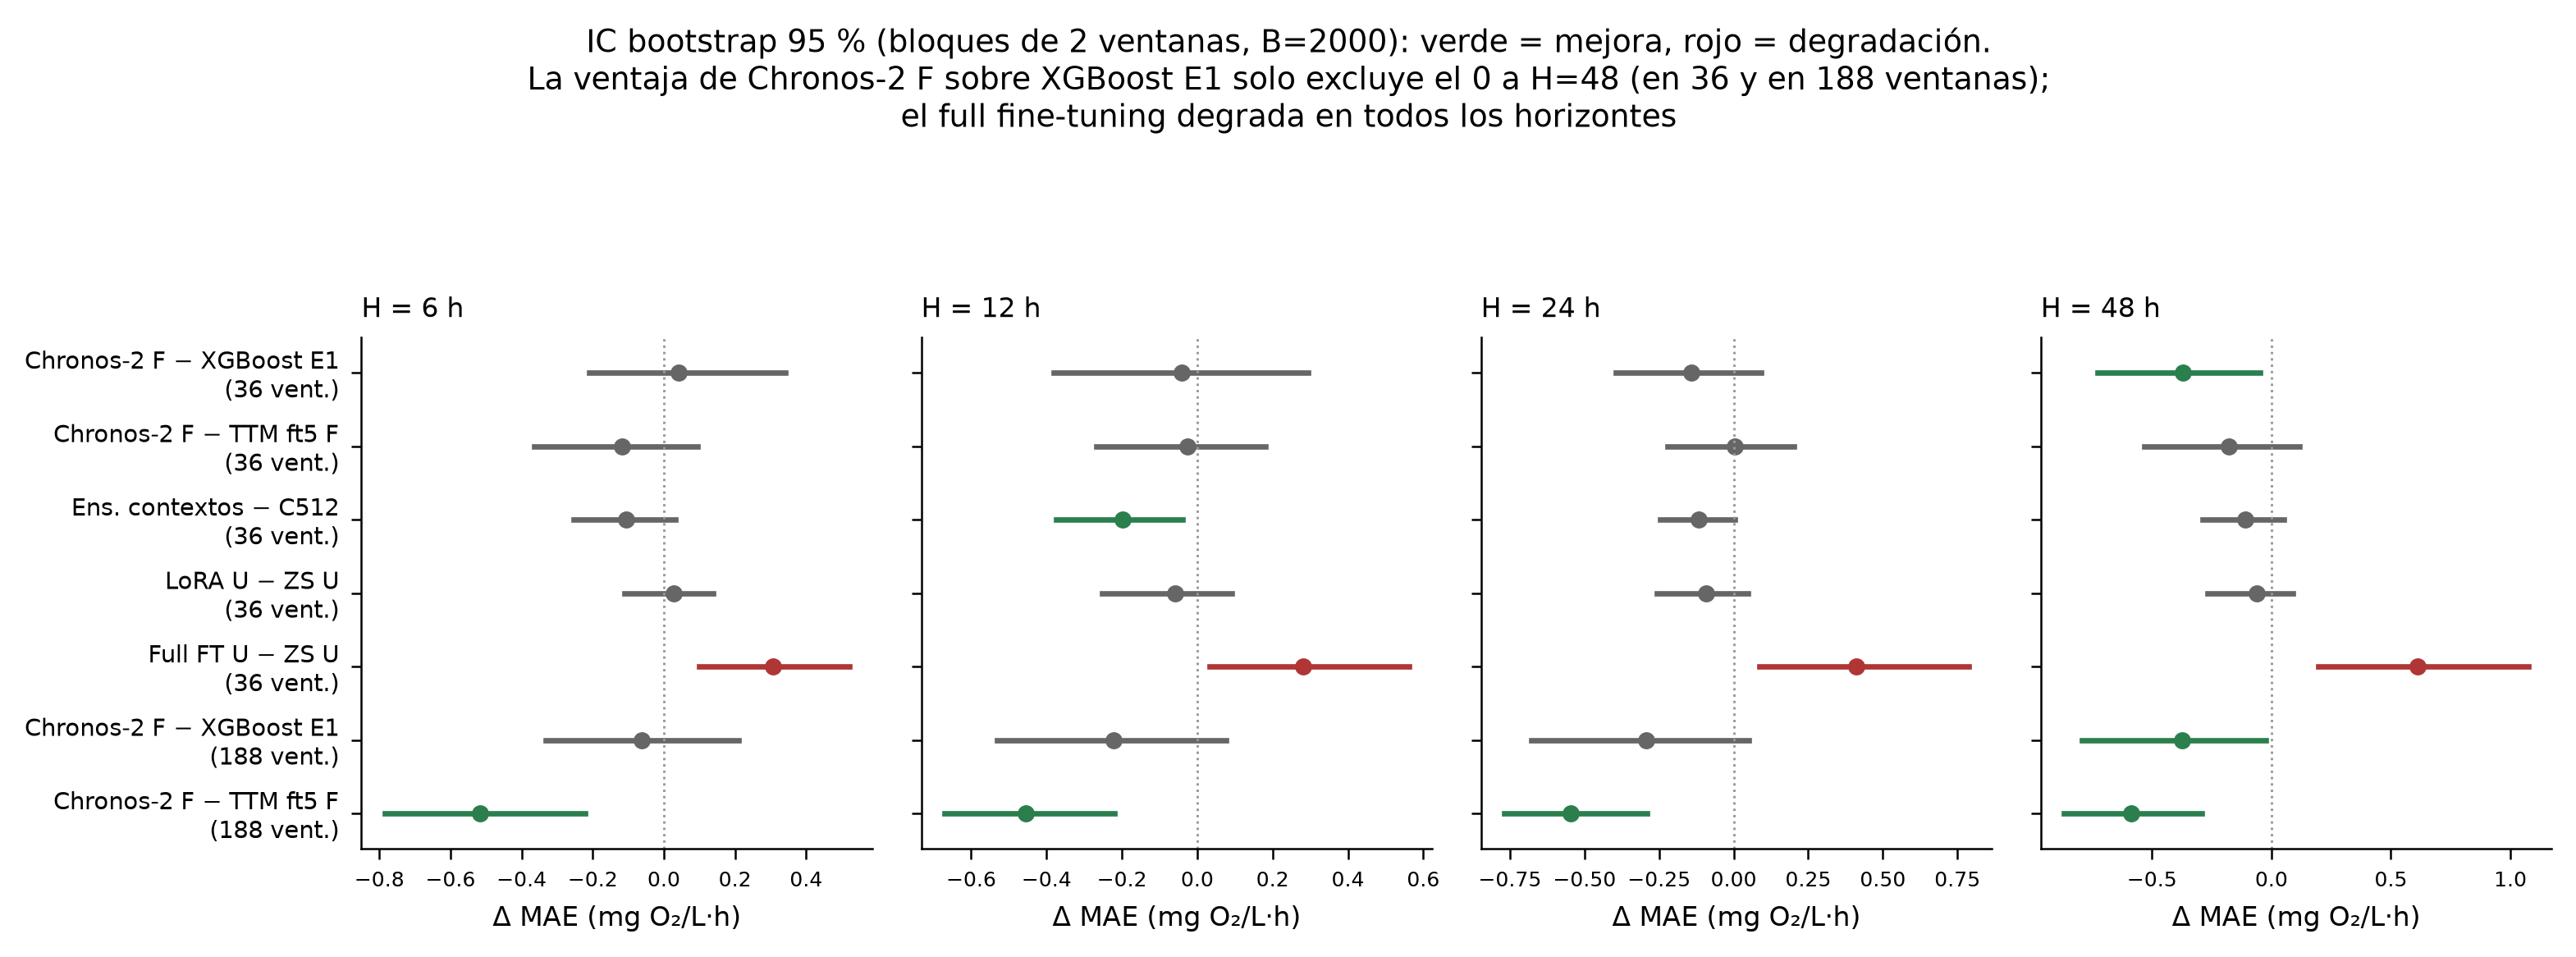

In [11]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df_boot = pd.read_csv("results/bootstrap_ic.csv")
HORIZONS = [6, 12, 24, 48]
d = df_boot[df_boot.tipo=="dif"].copy()
ETIQ = {("c2_zs_F_C256","xgb_E1"): "Chronos-2 F − XGBoost E1",
        ("c2_zs_F_C256","ttm_ft5_F"): "Chronos-2 F − TTM ft5 F",
        ("ens_ctx_F","c2_zs_F_C512"): "Ens. contextos − C512",
        ("c2_lora_U","c2_zs_U_C512"): "LoRA U − ZS U",
        ("c2_full_U","c2_zs_U_C512"): "Full FT U − ZS U"}
orden = [("36", k) for k in ETIQ] + [("188", ("c2_zs_F_C256","xgb_E1")), ("188", ("c2_zs_F_C256","ttm_ft5_F"))]
labels = [f"{ETIQ[k]}\n({u} vent.)" for u, k in orden]
fig, axes = plt.subplots(1, 4, figsize=(10.5, 3.4), sharey=True)
for ax, H in zip(axes, HORIZONS):
    ys = np.arange(len(orden))[::-1]
    for y_, (u, (A, B_)) in zip(ys, orden):
        r = d[(d.universo.astype(str)==u) & (d.A==A) & (d.B==B_) & (d.H==H)].iloc[0]
        col = "#b03636" if r.IC_lo > 0 else ("#2a7f4d" if r.IC_hi < 0 else "#666666")
        ax.plot([r.IC_lo, r.IC_hi], [y_, y_], "-", color=col, lw=1.6)
        ax.plot(r.valor, y_, "o", color=col, ms=4)
    ax.axvline(0, color="#999999", lw=0.7, ls=":")
    ax.set_title(f"H = {H} h", fontsize=8)
    ax.set_xlabel("Δ MAE (mg O₂/L·h)")
    ax.margins(y=0.08)
axes[0].set_yticks(np.arange(len(orden))[::-1]); axes[0].set_yticklabels(labels, fontsize=7)
fig.suptitle("IC bootstrap 95 % (bloques de 2 ventanas, B=2000): verde = mejora, rojo = degradación.\n"
             "La ventaja de Chronos-2 F sobre XGBoost E1 solo excluye el 0 a H=48 (en 36 y en 188 ventanas);\n"
             "el full fine-tuning degrada en todos los horizontes",
             fontsize=9, y=1.12)
fig.tight_layout()
fig.savefig("figures/fig_ic_diferencias.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Auditoría de fugas del preprocesamiento

Con el parquet bruto y el limpio: (a) horas imputadas (`our_imputed`, interpolación de huecos ≤6 h)
dentro del contexto de 512 h de cada ventana; (b) tramos imputados que **cruzan t0** (el tramo
contiene t0: sus valores anteriores a t0 se interpolaron usando la primera observación válida
posterior al tramo, que es futura respecto al origen — fuga); (c) revisión de la detección de
atípicos (mediana/MAD móvil con ventana **centrada** de ±24 h: no causal por construcción).

In [12]:
raw = pq.read_table("data/biologico-1.parquet").to_pandas()
imput = df["our_imputed"].to_numpy()
outl = df["our_outlier"].to_numpy()

# tramos imputados [a, b] (índices consecutivos con our_imputed=True)
runs = []
in_run = False
for k, v in enumerate(imput):
    if v and not in_run: a = k; in_run = True
    if not v and in_run: runs.append((a, k-1)); in_run = False
if in_run: runs.append((a, len(imput)-1))
print(f"tramos imputados totales: {len(runs)} | horas imputadas: {imput.sum()}")

def auditar(ilocs, etiqueta):
    filas = []
    for i in ilocs:
        ctx = slice(i-511, i+1)
        n_imp = int(imput[ctx].sum())
        n_out = int(outl[ctx].sum())
        cruza = any(a_ <= i <= b_ for a_, b_ in runs)
        # horas imputadas en las últimas 24 h del contexto (flag de atípico no causal cerca de t0)
        n_imp_24 = int(imput[i-23:i+1].sum())
        filas.append({"universo": etiqueta, "origen": str(df.index[i]), "n_imputadas_ctx": n_imp,
                      "pct_imputadas": round(100*n_imp/512, 2), "n_outlier_ctx": n_out,
                      "imputadas_ultimas24h": n_imp_24, "tramo_cruza_t0": cruza})
    return pd.DataFrame(filas)

aud36 = auditar(test_ilocs, "36_protocolo")
blo_orig = sorted(win_blo[win_blo.config=="xgb_E1"].origen.unique())
blo_ilocs = [df.index.get_loc(pd.Timestamp(t)) for t in blo_orig]
aud188 = auditar(blo_ilocs, "188_bloques")
aud = pd.concat([aud36, aud188], ignore_index=True)
aud.to_csv("results/auditoria_fugas.csv", index=False)

for uni, g in aud.groupby("universo"):
    print(f"\n{uni}: {len(g)} ventanas | con imputadas en contexto: {(g.n_imputadas_ctx>0).sum()} "
          f"| % horas imputadas medio: {g.pct_imputadas.mean():.2f}% (máx {g.pct_imputadas.max():.2f}%) "
          f"| tramos que cruzan t0: {int(g.tramo_cruza_t0.sum())} "
          f"| imputadas en las últimas 24 h: {int((g.imputadas_ultimas24h>0).sum())} ventanas")

# detección de atípicos: ventana centrada (win=49, center=True) -> NO causal por construcción.
# Efecto: los flags de las últimas 24 h del contexto pudieron usar observaciones posteriores a t0.
# El flag solo enmascara el valor (que luego se imputa o rompe segmento); no modifica valores no marcados.
n_out_24 = sum(int(outl[i-23:i+1].sum()) > 0 for i in test_ilocs + blo_ilocs)
print(f"\nventanas (36+188) con flag de atípico en las últimas 24 h del contexto: {n_out_24}")
if aud.tramo_cruza_t0.any():
    print("\nATENCIÓN: hay tramos imputados que cruzan t0 -> re-evaluación con contexto truncado en la celda siguiente")
else:
    print("\nNingún tramo imputado cruza t0: la imputación no introduce fuga en los orígenes evaluados")

tramos imputados totales: 92 | horas imputadas: 177

188_bloques: 188 ventanas | con imputadas en contexto: 162 | % horas imputadas medio: 0.53% (máx 2.73%) | tramos que cruzan t0: 0 | imputadas en las últimas 24 h: 22 ventanas

36_protocolo: 36 ventanas | con imputadas en contexto: 30 | % horas imputadas medio: 0.60% (máx 1.37%) | tramos que cruzan t0: 0 | imputadas en las últimas 24 h: 5 ventanas

ventanas (36+188) con flag de atípico en las últimas 24 h del contexto: 19

Ningún tramo imputado cruza t0: la imputación no introduce fuga en los orígenes evaluados


In [13]:
# re-evaluación condicional: si algún tramo imputado cruza t0, se re-evalúa Chronos-2 ZS F C256
# en esas ventanas con el contexto truncado justo antes del tramo
afectadas = aud[aud.tramo_cruza_t0]
if len(afectadas) == 0:
    print("Sin ventanas afectadas: no procede re-evaluación.")
else:
    pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
    cambios = []
    for _, r in afectadas.iterrows():
        i = df.index.get_loc(pd.Timestamp(r.origen))
        a_ = next(a for a, b in runs if a <= i <= b)
        dicts = c2_ctx([i], 256, True)
        d_tr = c2_ctx([a_-1], 256, True)   # contexto truncado antes del tramo
        qs, means = pipe.predict_quantiles(dicts, prediction_length=48)
        P_full = means[0].squeeze().numpy()
        qs, means = pipe.predict_quantiles(d_tr, prediction_length=48 + (i - a_ + 1))
        P_tr = means[0].squeeze().numpy()[-(48):]
        yv_ = df['our'].iloc[i+1:i+49].to_numpy()
        cambios.append({"origen": r.origen, "MAE_original": float(np.abs(yv_-P_full).mean()),
                        "MAE_truncado": float(np.abs(yv_-P_tr).mean())})
    print(pd.DataFrame(cambios).round(3).to_string(index=False))
    del pipe; torch.cuda.empty_cache()

Sin ventanas afectadas: no procede re-evaluación.


## 7. Conclusión

Ver `resumen_rigor.md` para la síntesis: la configuración honesta elegida en validación y su MAE de
test, qué contrastes sobreviven a Holm/BH, el MASE frente al naive estacional, la varianza entre
semillas comparada con los efectos publicados, los IC bootstrap de la hipótesis primaria y el
resultado de la auditoría de fugas.